# Memory Experiment — 4D Geometric Codes

High-rate codes from rotated 4-dimensional toric lattices (arXiv:2506.15130).  
All codes have k=6 logical qubits. L matrix entries follow Table 1 of the paper.

| Code     | Det |  n  | d  | a₁₁ | a₁₂ | a₁₃ | a₁₄ | a₂₂ | a₂₃ | a₂₄ | a₃₃ | a₃₄ | a₄₄ |
|----------|-----|-----|----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Det2     |   2 |  12 |  2 |   1 |   0 |   0 |   1 |   1 |   0 |   1 |   1 |   0 |   2 |
| Det3     |   3 |  18 |  3 |   1 |   0 |   0 |   1 |   1 |   0 |   1 |   1 |   1 |   3 |
| Det5     |   5 |  30 |  4 |   1 |   0 |   0 |   1 |   1 |   0 |   2 |   1 |   3 |   5 |
| Det9     |   9 |  54 |  6 |   1 |   0 |   0 |   5 |   1 |   0 |   6 |   1 |   7 |   9 |
| Hadamard |  16 |  96 |  8 |   1 |   1 |   1 |   1 |   2 |   0 |   2 |   2 |   2 |   4 |
| Det16    |  16 |  96 |  8 |   1 |   0 |   0 |   3 |   1 |   0 |   5 |   1 |   7 |  16 |
| Det18    |  18 | 108 |  9 |   1 |   0 |   0 |   3 |   1 |   0 |   5 |   1 |   7 |  18 |
| Det45    |  45 | 270 | 15 |   1 |   0 |   1 |   6 |   1 |   0 |  11 |   3 |   9 |  15 |

k=6 for all codes. Det68 ([[408,6,≤18]]) and Det152 ([[912,6,≤30]]) omitted (d is only an upper bound).

In [1]:
import sys
from pathlib import Path

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.memory import MemoryExperiment
from lightstim.noise.config import NoiseConfig
from lightstim.qec_code.four_d_geo_code import FourDGeoCode, FourDGeoCodeExtractionBlock
from lightstim.qec_code.four_d_geo_code.configs import FOUR_D_CONFIGS

In [2]:
p = 1e-3
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

In [3]:
def build_4d_memory(name, rounds=3, basis="Z", noise_model="circuit_level"):
    cfg = FOUR_D_CONFIGS[name]
    code = FourDGeoCode(L=cfg["L"], d=cfg["d"])
    system = QECSystem()
    system.add_patch(code, name=name)
    exp = MemoryExperiment(
        qec_system=system,
        extraction_block_class=FourDGeoCodeExtractionBlock,
        rounds=rounds,
        noise_params=noise_params,
        noise_model=noise_model,
        basis=basis,
    )
    circuit = exp.build()
    print(f"{name}  [[n={cfg['n']}, k={cfg['k']}, d={cfg['d']}]]  "
          f"total_qubits={circuit.num_qubits}  detectors={circuit.num_detectors}")
    return circuit, code

## Memory Experiment - Check

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det3  [[n=18, k=6, d=3]]  total_qubits=42  detectors=84


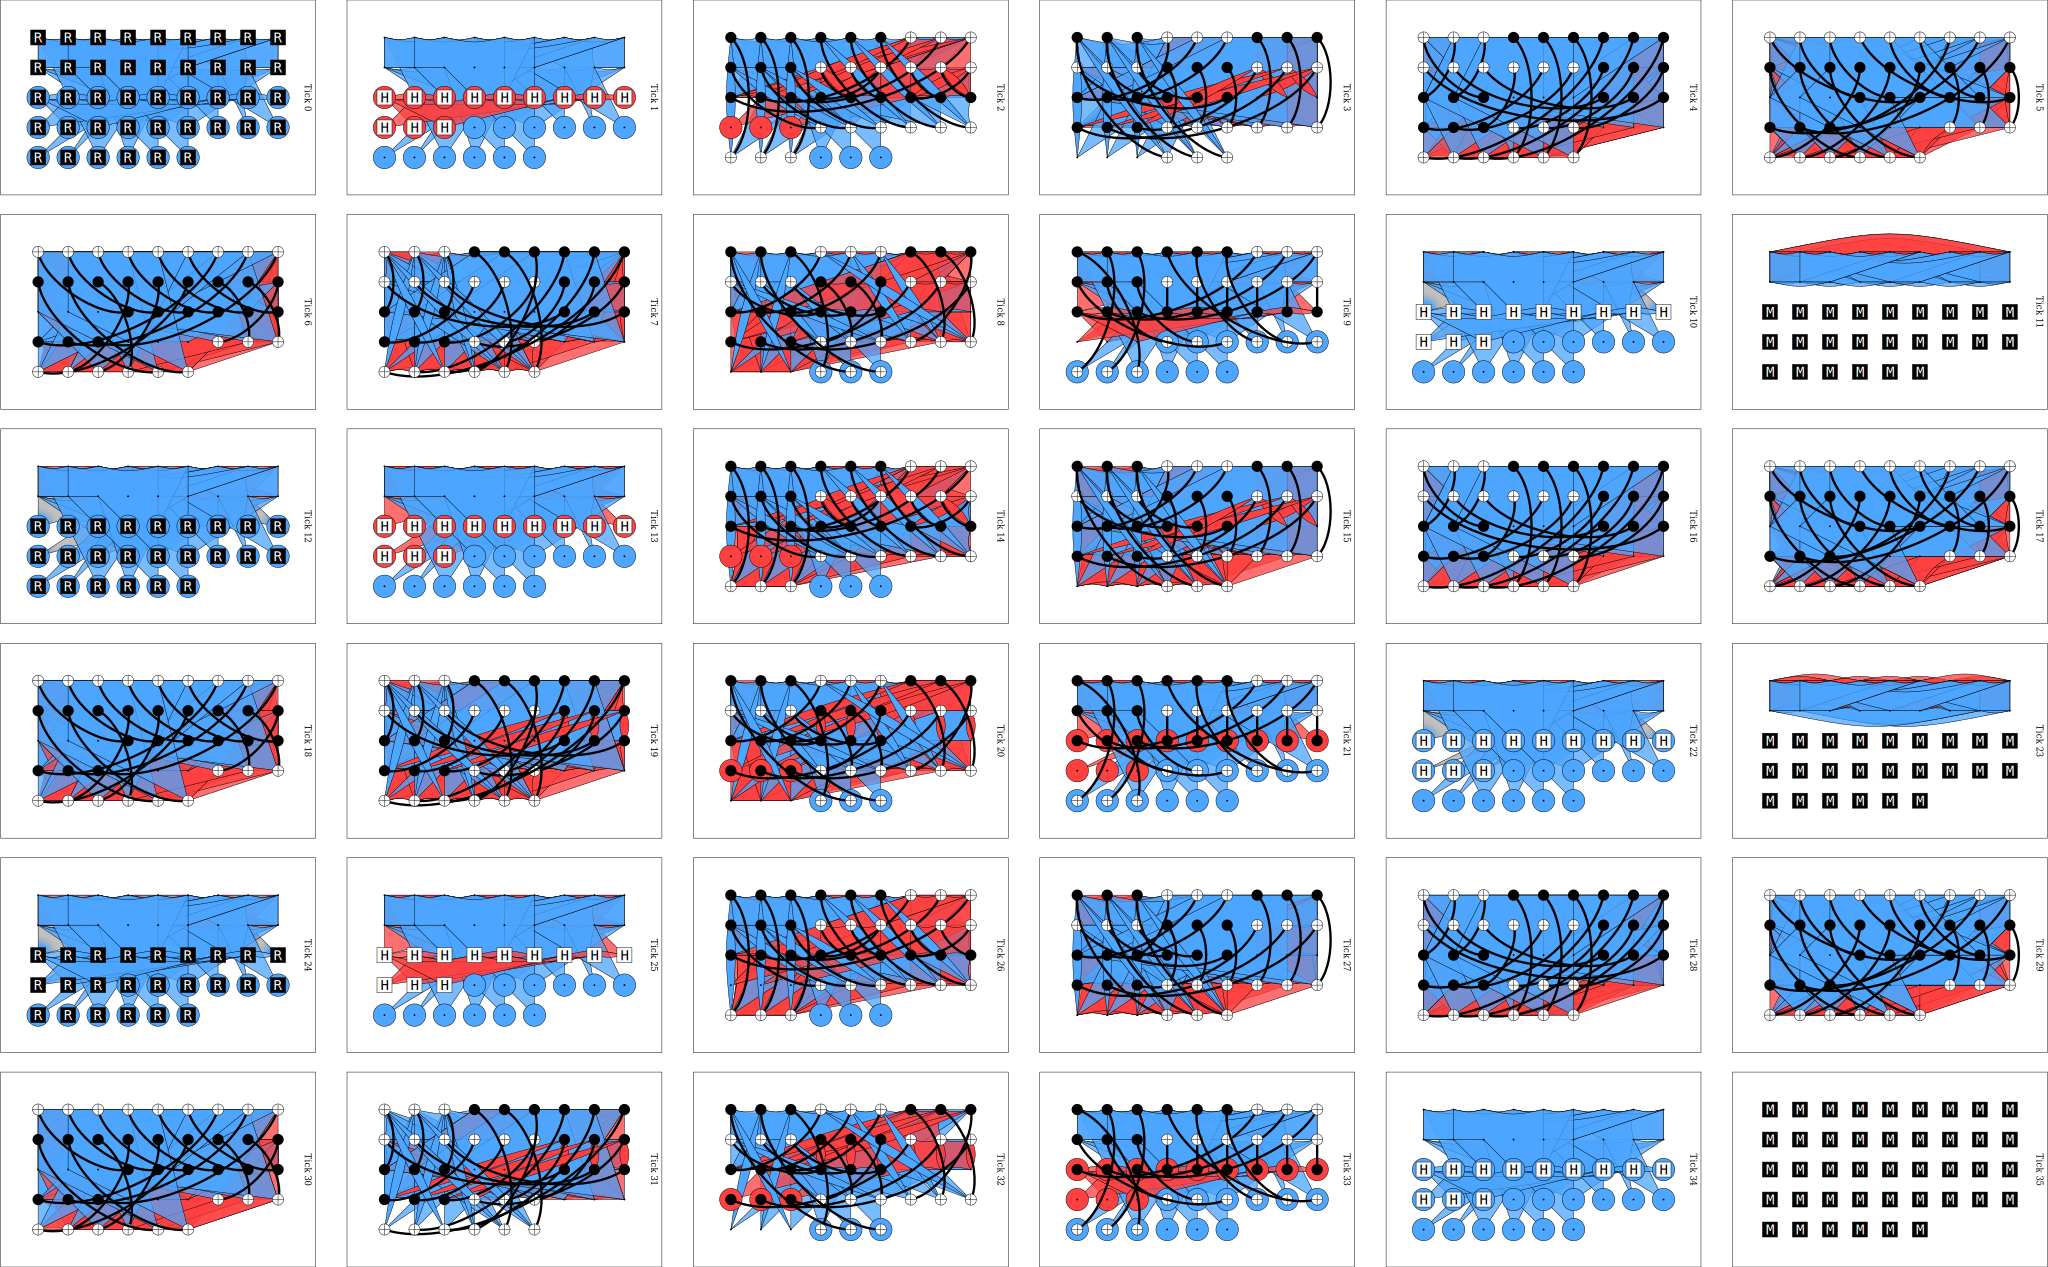

In [4]:
code_name = "det3" # det2, det3, det5, det9, hadamard, det16, det18, det45
basis = "Z" # "Z" or "X"
circuit, code = build_4d_memory(code_name, basis=basis)
circuit.without_noise().diagram("detslice-with-ops-svg")
# circuit.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"]) # L0, L1, L2, ...

## All Codes Summary

In [5]:
print(f"{'Code':<12} {'[[n,k,d]]':<18} {'qubits':>8} {'detectors':>10}")
print("-" * 52)
for name in FOUR_D_CONFIGS:
    cfg = FOUR_D_CONFIGS[name]
    code = FourDGeoCode(L=cfg["L"], d=cfg["d"])
    system = QECSystem()
    system.add_patch(code, name=name)
    exp = MemoryExperiment(
        qec_system=system,
        extraction_block_class=FourDGeoCodeExtractionBlock,
        rounds=cfg["d"],
        noise_params=noise_params,
        noise_model="circuit_level",
        basis="Z",
    )
    circ = exp.build()
    nkd = f"[[{cfg['n']},{cfg['k']},{cfg['d']}]]"
    print(f"{name:<12} {nkd:<18} {circ.num_qubits:>8} {circ.num_detectors:>10}")

Code         [[n,k,d]]            qubits  detectors
----------------------------------------------------
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det2         [[12,6,2]]               28         18
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det3         [[18,6,3]]               42         84
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det5         [[30,6,4]]               70        176
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying firs

Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det9         [[54,6,6]]              126        456
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
hadamard     [[96,6,8]]              224       1062
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det16        [[96,6,8]]              224       1062
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
det18        [[108,6,9]]             252       1338
Writing coordinates...
Initializing...
Building syndr